In [106]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from matplotlib.pylab import rcParams
rcParams['figure.figsize']=20,10
from keras.models import Sequential
from keras.layers import LSTM,Dropout,Dense


from sklearn.preprocessing import MinMaxScaler

In [107]:
df=pd.read_csv("Nifty_50_with_changes_.csv")
df

,Date,open,high,low,close,sma5,sma10,sma15,sma20,ema5,...,fastd,fastksr,fastdsr,ULTOSC,WILLR,ATR,Trange,TYPPRICE,HT_DCPERIOD,BETA
0,6-9-2022,16263.85,16492.80,16243.85,16478.10,15975.71,15693.490,15711.476670,15742.0225,16047.868940,...,89.971687,100.000000,100.000000,54.481072,-1.122652,285.430520,291.00,16404.916670,21.905630,0.543621
1,6-8-2022,16474.95,16514.30,16293.35,16356.25,16108.53,15787.785,15748.620000,15760.3450,16150.662620,...,89.109417,80.470659,93.490220,52.508022,-11.875423,280.824768,220.95,16387.966670,21.206620,1.152622
2,6-7-2022,16469.60,16487.25,16347.10,16416.35,16245.38,15865.540,15786.363330,15790.6200,16239.225080,...,89.316824,85.879016,88.783225,59.487656,-7.359681,270.776570,140.15,16416.900000,20.847854,0.997493
3,6-6-2022,16530.70,16610.95,16444.55,16569.55,16404.41,15987.480,15835.530000,15827.3300,16349.333390,...,86.756643,100.000000,88.783225,59.306695,-2.900074,265.335387,194.60,16541.683330,20.982053,0.989819
4,6-3-2022,16761.65,16793.85,16567.90,16584.30,16480.91,16116.560,15894.533330,15868.9425,16427.655590,...,80.219517,100.000000,95.293005,56.144553,-13.011891,262.522145,225.95,16648.683330,21.093135,0.265151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5577,1-7-2000,1616.60,1628.25,1597.20,1613.30,1612.98,1614.180,1611.026667,1602.3350,1613.551843,...,47.179279,71.049699,57.016566,45.089907,-47.070789,58.703545,35.70,1612.916667,20.965225,0.902019
5578,1-6-2000,1595.80,1639.00,1595.80,1617.60,1612.22,1615.830,1612.260000,1603.2300,1614.901228,...,60.906610,77.780280,82.943326,49.079343,-43.572010,57.596149,43.20,1617.466667,20.803155,1.125874
5579,1-5-2000,1634.55,1635.50,1555.05,1595.80,1606.42,1611.930,1611.720000,1603.1250,1608.534152,...,51.869391,44.949344,64.593108,48.013530,-61.310008,59.228567,80.45,1595.450000,20.668914,1.169450
5580,1-4-2000,1594.40,1641.95,1594.40,1638.70,1619.66,1615.130,1615.206667,1605.6600,1618.589435,...,60.273340,100.000000,74.243208,54.334542,-26.403580,58.394383,47.55,1625.016667,20.549754,1.430338


In [108]:
df["Date"]=pd.to_datetime(df.Date,format="%m-%d-%Y")
df.index=df['Date']

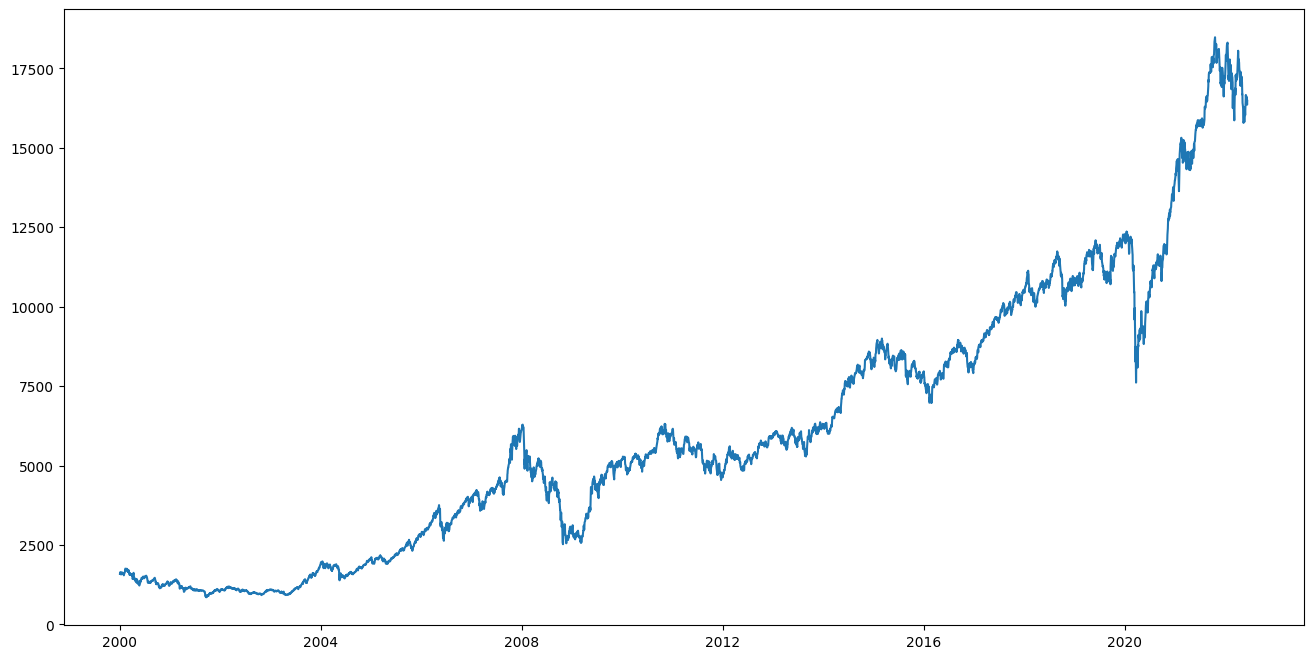

In [109]:
plt.figure(figsize=(16,8))
plt.plot(df["close"],label='close Price history')

In [110]:
data=df.sort_index(ascending=True,axis=0)
new_dataset=pd.DataFrame(index=range(0,len(df)),columns=['Date','close'])

for i in range(0,len(data)):
    new_dataset["Date"][i]=data['Date'][i]
    new_dataset["close"][i]=data["close"][i]

In [111]:
scaler=MinMaxScaler(feature_range=(0,1))
final_dataset=new_dataset.values

In [112]:
valid_data

,close,Predictions
Date,,
2003-12-09,1675.8,1544.133667
2003-12-10,1686.9,1550.020508
2003-12-11,1695.4,1556.634277
2003-12-12,1698.9,1563.669678
2003-12-15,1723.9,1570.411743
...,...,...
2022-06-03,16584.3,13609.442383
2022-06-06,16569.55,13647.890625
2022-06-07,16416.35,13675.662109


In [113]:
new_dataset

,Date,close
0,2000-01-03 00:00:00,1592.2
1,2000-01-04 00:00:00,1638.7
2,2000-01-05 00:00:00,1595.8
3,2000-01-06 00:00:00,1617.6
4,2000-01-07 00:00:00,1613.3
...,...,...
5577,2022-06-03 00:00:00,16584.3
5578,2022-06-06 00:00:00,16569.55
5579,2022-06-07 00:00:00,16416.35
5580,2022-06-08 00:00:00,16356.25


In [114]:
new_dataset.index=new_dataset.Date
new_dataset

,Date,close
Date,,
2000-01-03,2000-01-03 00:00:00,1592.2
2000-01-04,2000-01-04 00:00:00,1638.7
2000-01-05,2000-01-05 00:00:00,1595.8
2000-01-06,2000-01-06 00:00:00,1617.6
2000-01-07,2000-01-07 00:00:00,1613.3
...,...,...
2022-06-03,2022-06-03 00:00:00,16584.3
2022-06-06,2022-06-06 00:00:00,16569.55
2022-06-07,2022-06-07 00:00:00,16416.35


In [115]:
new_dataset['Date'] = pd.to_datetime(new_dataset.index)
new_dataset

,Date,close
Date,,
2000-01-03,2000-01-03,1592.2
2000-01-04,2000-01-04,1638.7
2000-01-05,2000-01-05,1595.8
2000-01-06,2000-01-06,1617.6
2000-01-07,2000-01-07,1613.3
...,...,...
2022-06-03,2022-06-03,16584.3
2022-06-06,2022-06-06,16569.55
2022-06-07,2022-06-07,16416.35


In [116]:
new_dataset.drop("Date",axis=1,inplace=True)
new_dataset

,close
Date,
2000-01-03,1592.2
2000-01-04,1638.7
2000-01-05,1595.8
2000-01-06,1617.6
2000-01-07,1613.3
...,...
2022-06-03,16584.3
2022-06-06,16569.55
2022-06-07,16416.35


In [117]:
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(new_dataset)
new_dataset

,close
Date,
2000-01-03,1592.2
2000-01-04,1638.7
2000-01-05,1595.8
2000-01-06,1617.6
2000-01-07,1613.3
...,...
2022-06-03,16584.3
2022-06-06,16569.55
2022-06-07,16416.35


In [118]:
x_train_data,y_train_data=[],[]

In [119]:
for i in range(60,len(train_data)):
    x_train_data.append(scaled_data[i-60:i,0])
    y_train_data.append(scaled_data[i,0])

In [120]:
x_train_data,y_train_data=np.array(x_train_data),np.array(y_train_data)

In [121]:
x_train_data=np.reshape(x_train_data,(x_train_data.shape[0],x_train_data.shape[1],1))

In [122]:
lstm_model=Sequential()

In [123]:
lstm_model.add(LSTM(units=50,return_sequences=True,input_shape=(x_train_data.shape[1],1)))

In [124]:
lstm_model.add(LSTM(units=50))

In [125]:
lstm_model.add(Dense(1))

In [126]:
inputs_data=new_dataset[len(new_dataset)-len(valid_data)-60:].values

In [127]:
inputs_data=inputs_data.reshape(-1,1)

In [128]:
inputs_data=scaler.transform(inputs_data)

C:\Users\Firdaush Alam\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [129]:
lstm_model.compile(loss='mean_squared_error',optimizer='adam')

In [130]:
lstm_model.fit(x_train_data,y_train_data,epochs=1,batch_size=1,verbose=2)

927/927 - 18s - loss: 2.2928e-05 - 18s/epoch - 20ms/step


In [131]:
X_test=[]
for i in range(60,inputs_data.shape[0]):
    X_test.append(inputs_data[i-60:i,0])
X_test=np.array(X_test)

In [132]:
X_test=np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))

In [133]:
predicted_closing_price=lstm_model.predict(X_test)

144/144 [==============================] - 3s 10ms/step


In [134]:
predicted_closing_price=scaler.inverse_transform(predicted_closing_price)

In [135]:
lstm_model.save("saved_model.h5")

In [136]:
train_data=new_dataset[:987]

In [137]:
valid_data=new_dataset[987:]

In [138]:
valid_data['Predictions']=predicted_closing_price

C:\Users\Firdaush Alam\AppData\Local\Temp\ipykernel_2508\1898203866.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_data['Predictions']=predicted_closing_price


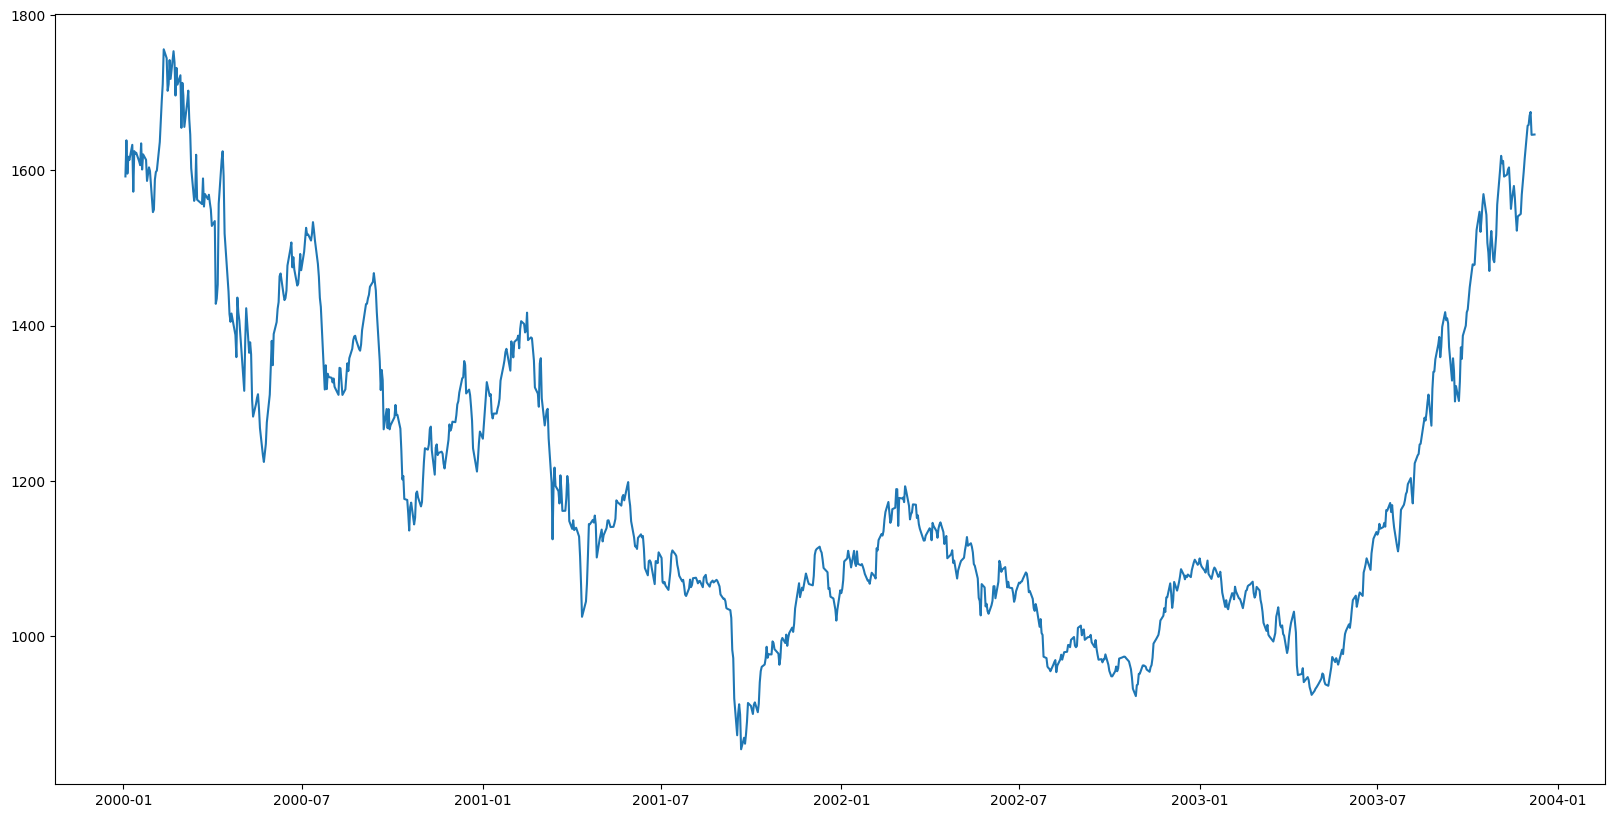

In [139]:
plt.plot(train_data["close"])

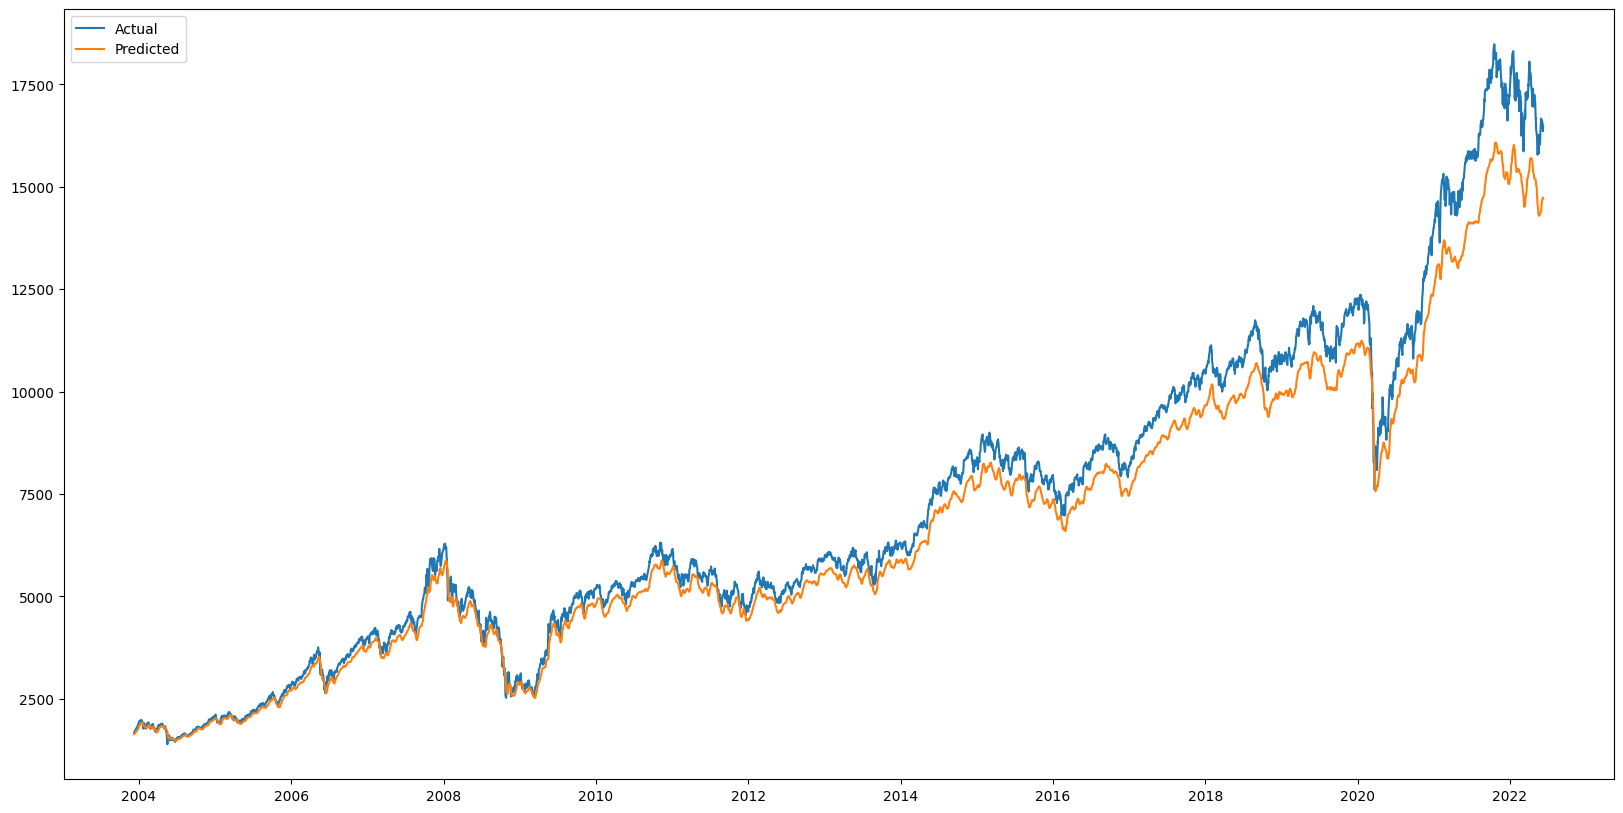

In [140]:
plt.plot(valid_data['close'], label='Actual')
plt.plot(valid_data['Predictions'], label='Predicted')
plt.legend()
plt.show()